# Лабораторная работа №2

ФИО:   
Группа:

Отправлять можно следующими способами:
1. Запушить этот ноутбук в GitHub в репозиторий, где у вас лежат ноутбуки с лабами

Deadlines:
- Занятие №6 в семестре (Занятие №2 очное)

Что необходимо сделать:  
**В общих чертах просто провести EDA** (но обычно это не бывает просто)
## Читайте задание внимательно

Исходные данные:
1. В [табличке](https://docs.google.com/spreadsheets/d/1k2MYXEp_OVQrink_XRC1PwoM0ZuNMeNz4VTWY7cI3hE/edit?usp=sharing) необходимо узнать название своего датасета
2. Скачать нужны вам данные можно в [Google Drive](https://drive.google.com/drive/folders/1Phm-Fq1GL-VX7NS-DCEMRh_Fo1wU7DQ9?usp=sharing)
  
---
Теперь по пунктам, что я от вас жду:  
1. **Найти** в таблице (из исходных данных) название своего датасета
2. **Описать** кратко постановку задачи, что от вас хотят. Какие есть переменные. Целевое событие непрерывно (предсказываем число от -$\infty$ до $\infty$) либо дискретно (предсказываем класс из конечного множества вариантов, например 0 или 1, или какое-то число в диапазоне [0; 10])
3. Построить распределение целевой переменной в виде гистограммы, сделать промежуточные выводы (обратите внимание на однородоность распределения и возможный дисбаланс). Посчитайте количество уникальных значений целевой переменной.
4. Выведите основные статистики по переменным в датасете (для этого есть готовый метод в pandas, он считает count, min, max, mean, 25%, 50% и пр.). Это делается **одним** методом (вы его знаете).
5. Выведите основную информацию по датасету (сколько всего колонок, каких они типов, сколько в них non-null элементов). Это делается **одним** методом (вы его знаете).
6. Посчитайте количество пропусков (NaN, Null, null, None) элементов во всех колонках. Предположите, почему эти пропуски могли возникнуть, и как их можно было бы заменить.
7. Постройте гистограммы 5 любых признаков (из множества `X`, или как оно изначально у нас называется `data.data`). Если видите какое-то смещение, несимметричность и прочее, опишите это словами в ноутбуке.
8. Постройте графики зависимости 5 любых (на ваш выбор) переменных от целевой переменной (если переменных меньше, чем 5, то сделайте столько, сколько получится). Сделайте вывод, можно ли использовать эти переменные для прогнозирования целевой переменной (иначе говоря, есть ли какая-то взаимосвязь между y-переменной и X-переменной)  
9. _extra_ (необязательно). Посмотрите на зависимость двух переменных одновременно от целевой переменной. То есть по оси OX должна быть переменная $X_{n}$, по оси OY -- переменная $X_{k}$. И у вас будет две кривые (два облака точек) в разрезе целевой переменной. Либо вы можете построить похожее для категориальных признаков, но необходимо будет прочитать про heatmap.

---
P.S.  
Просьба -- делать каждое задание в отдельных ячейках и с отдельными заголовками (как пункт 1 и 2 в этом ноутбуке) типа  
- Заголовок
- Ячейки с кодом
- Другой заголовок
- Другие ячейки с кодом

## 0. Пример импорта данных

In [278]:
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv', sep=',')  # если нужно, можно поменять разделитель
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## 2. Описание постановки задачи
Основная задача - научиться предсказывать появление проблем со сном у человека, по его образу жизни, профессии, возрасту и другим параметрам
Для этого нужно определить признаки, которые наиболее сильно влияют на шанс появления болезни
Целевое событие дискретное, имеет три варианта (две болезни и NaN), далее я буду исходить из предположения, что NaN == человек не болен. Мы можем научиться определять шансы каждого из 3 исходов, либо шансы появления любой болезни

## 3. Распределение целевой переменной

[nan 'Sleep Apnea' 'Insomnia']
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


<Axes: xlabel='Sleep Disorder'>

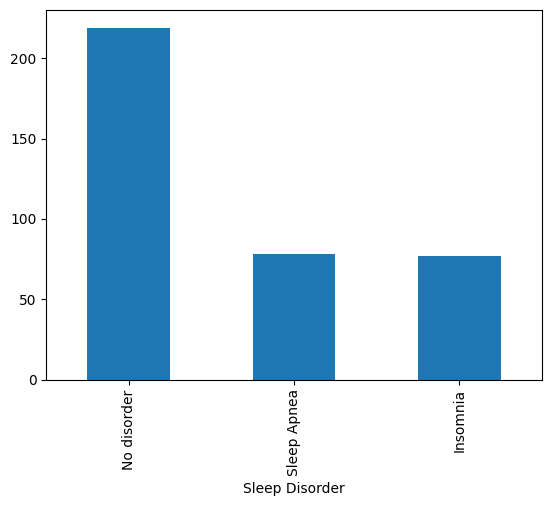

In [279]:
print(data['Sleep Disorder'].unique())
print(data['Sleep Disorder'].value_counts())
data['Sleep Disorder'].fillna('No disorder').value_counts().plot(kind='bar') # заменим NaN на нет болезни

## 4.Описание датасета


In [280]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## 5. Информация о датасете

In [281]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


## 6. Количество NaN в каждом столбце

In [282]:
data.isna().sum()


,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


## 7. Гистограммы 5 признаков

<Axes: xlabel='Gender'>

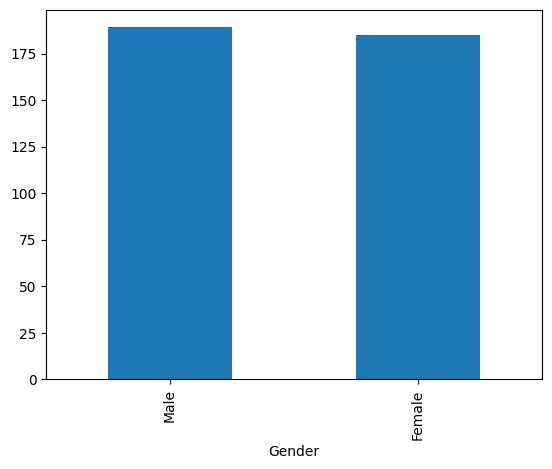

In [283]:
data.Gender.value_counts().plot(kind='bar') # Количество мужчин и женщин примерно равное

<Axes: xlabel='Occupation'>

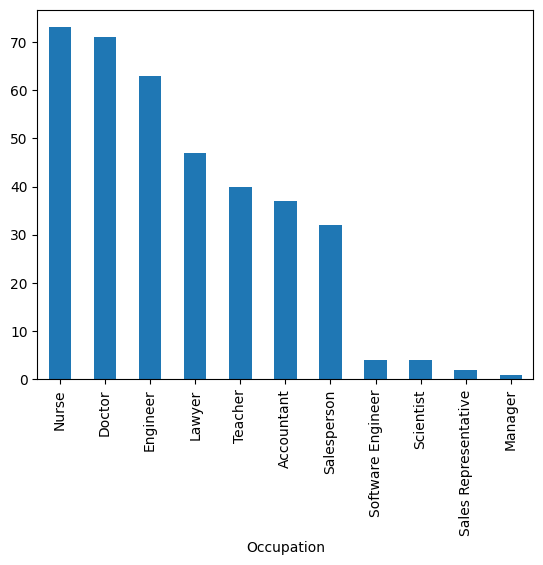

In [284]:
data.Occupation.value_counts().plot(kind='bar') # распредение по профессиям не равное, разработчиков, научных работников, торговых представителей и менеджеров меньше на порядок

27 59


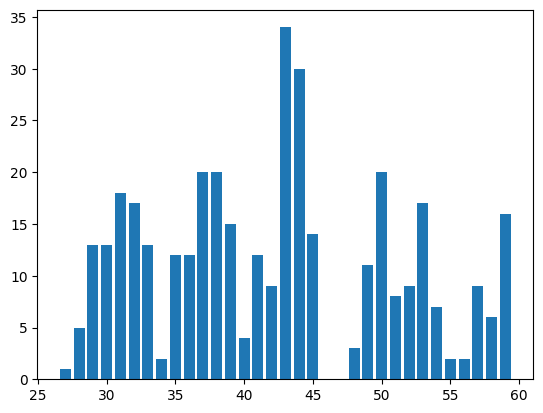

<BarContainer object of 9 artists>

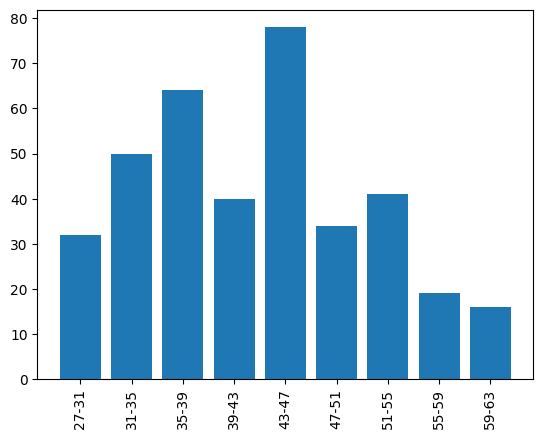

In [285]:
age_min, age_max = data.Age.min(), data.Age.max()
print(age_min, age_max) # разница в 32 года
d = {
    age: len(data[data['Age'] == age])
    for age in range(age_min, age_max + 1)
}
plt.bar(list(d.keys()), list(d.values())) # график не информативный, построим график по группам возрастов (8 групп)
plt.show()
step =  (age_max - age_min) // 8
borders = [i for i in range(age_min, age_max + 1, step)]
d = {
    f'{age}-{age+step}': len(data[(age <= data['Age']) & (data['Age'] < age + step)])
    for age in borders
}
plt.xticks(rotation=90)
plt.bar(list(d.keys()), list(d.values())) # график отдаленно напоминает нормальное распределение, больше всего людей возраста 43-47 лет

['Overweight' 'Normal' 'Obese' 'Normal Weight']


<Axes: xlabel='BMI Category'>

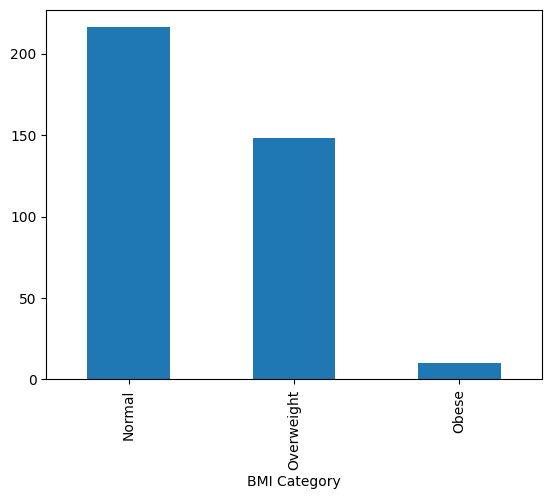

In [286]:
print(data['BMI Category'].unique()) # normal и normal weight - одно и то же, заменим на единое название
data['BMI Category'] = data['BMI Category'].replace('Normal Weight', 'Normal')
data['BMI Category'].value_counts().plot(kind='bar') # большинство людей нормального веса, на 50 человек меньше с лишним весом, ~5-10 человек с ожирением

## 7. Зависимость целевой переменной от признаков
так как в результате есть три варианта(2 болезни и не болен), обобщим две болезни в одну, а NaN заменим на не болен

In [287]:
df = data.copy()
df['Sleep Disorder'] = df['Sleep Disorder'].replace('Insomnia', 'Yes')
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No')
df['Sleep Disorder'] = df['Sleep Disorder'].replace('Sleep Apnea', 'Yes')
df['Sleep Disorder'].unique()

array(['No', 'Yes'], dtype=object)

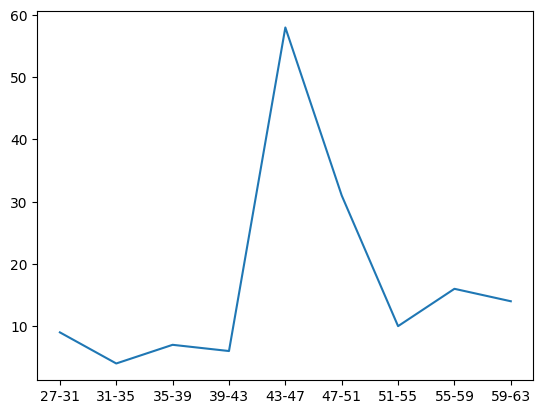

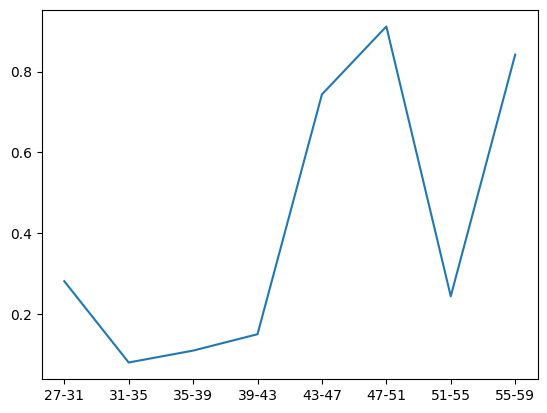

In [288]:
# зависимость количества заболевших от группы возрастов
d = {
    f'{age}-{age + step}': len(df[(df['Sleep Disorder'] == 'Yes') & (age <= df.Age) & (df.Age < age + step)])
    for age in range(age_min, age_max + 1, step)
}
plt.plot(list(d.keys()), list(d.values())) # сильный выброс в 39-51
plt.show()
plt.close()
# построим график по проценту больных в данном возрасте (так как количество людей не равное)
d = {
    f'{age}-{age + step}': len(df[(df['Sleep Disorder'] == 'Yes') & (df.Age < age + step) & (age <= df.Age)]) / len(df[(df.Age < age + step) & (age <= df.Age)])
    for age in range(age_min, age_max, step)
}
plt.plot(list(d.keys()), list(d.values())) # в возрасте 43-51 процент больных людей 80-90
plt.show()
plt.close()

array([6, 8, 7, 4, 3, 5])

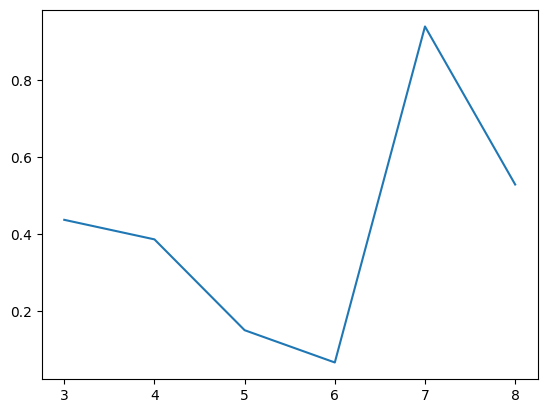

In [289]:
# зависимость от уровня стресса
d = {
    level: len(df[(df['Sleep Disorder'] == 'Yes') & (df['Stress Level'] == level)]) / len(df[df['Stress Level'] == level])
    for level in sorted(df['Stress Level'].unique())
}
plt.plot(list(d.keys()), list(d.values()))
df['Stress Level'].unique() # при уровне стреса 7 вероятность болезни 90-100%

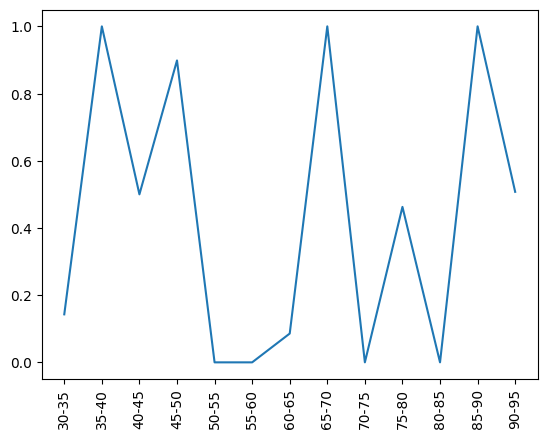

In [290]:
# от физ активности
min_phys = df['Physical Activity Level'].min()
max_phys = df['Physical Activity Level'].max()
d = {
    f'{level}-{level + 5}': len(df[(df['Physical Activity Level'] >= level) & (df['Physical Activity Level'] < level + 5) & (df['Sleep Disorder'] == 'Yes')]) / len(df[(df['Physical Activity Level'] >= level) & (df['Physical Activity Level'] < level + 5)])
    for level in range(min_phys, max_phys + 1, 5)
}
plt.xticks(rotation=90)
plt.plot(list(d.keys()), list(d.values())) # зависимость не видна

In [291]:
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


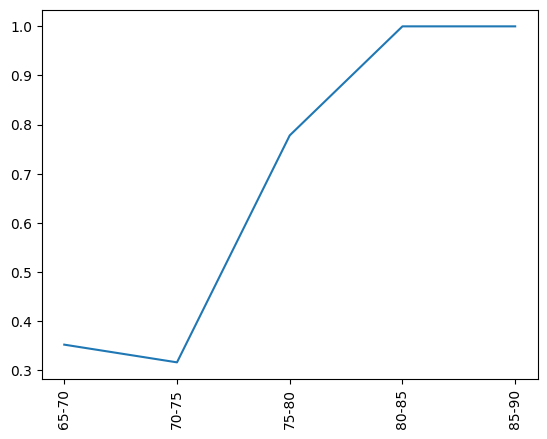

In [292]:
# от пульса
min_phys = df['Heart Rate'].min()
max_phys = df['Heart Rate'].max()
d = {
    f'{level}-{level + 5}': len(df[(df['Heart Rate'] >= level) & (df['Heart Rate'] < level + 5) & (df['Sleep Disorder'] == 'Yes')]) / len(df[(df['Heart Rate'] >= level) & (df['Heart Rate'] < level + 5)])
    for level in range(min_phys, max_phys + 1, 5)
}
plt.xticks(rotation=90)
plt.plot(list(d.keys()), list(d.values())) # видна  зависимость, больше пульс => выше вероятность болезни

## 8. Зависимость от двух параметров

In [293]:
# построим хитмапу по уровню стресса и полу
stress = sorted(df['Stress Level'].unique())
stress

[3, 4, 5, 6, 7, 8]

In [294]:
gender = sorted(df['Gender'].unique()) # 6x6
gender # 0 female, 1 male
gender = {'Male': 1, 'Female': 0}

In [295]:
import numpy as np
import seaborn as sns
hm = np.zeros((2, 6))

[[0.43283582 0.44262295 0.5        0.22222222 1.         0.94117647]
 [0.5        0.         0.13846154 0.02702703 0.92105263 0.13888889]]


<Axes: >

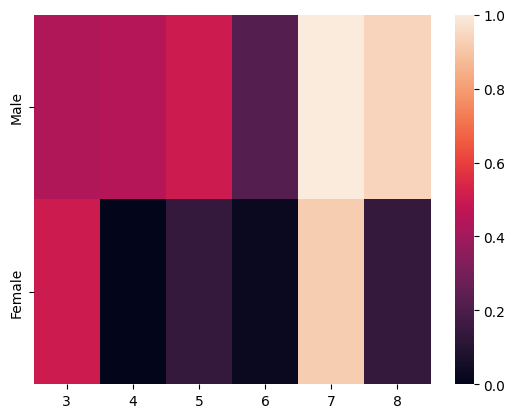

In [296]:
for g in gender:
  for st in stress:
    if len(df[(df['Stress Level'] == st) & (df['Gender'] == g)]) != 0:
      hm[gender[g]][st - 3] = len(df[(df['Stress Level'] == st) & (df['Gender'] == g) & (df['Sleep Disorder'] == 'Yes')]) / len(df[(df['Stress Level'] == st) & (df['Gender'] == g)])
print(hm)
sns.heatmap(hm, xticklabels=[3, 4, 5, 6, 7, 8], yticklabels=list(gender.keys()))